<a href="https://colab.research.google.com/github/PriyaVerma06/EDA-IPL/blob/fix-E2/fix_E2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

issue #9

In [4]:
# 1. Setup and Imports

import pandas as pd
import matplotlib.pyplot as plt

In [5]:
# 2. Load Data

df = pd.read_csv("https://raw.githubusercontent.com/iiitl/EDA-IPL/main/data/deliveries.csv")

In [6]:
# 3. Basic Inspection

print("Shape:", df.shape)
print("\nColumns:\n", df.columns)

Shape: (260920, 17)

Columns:
 Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs',
       'total_runs', 'extras_type', 'is_wicket', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='object')


In [8]:
# 4. Validate Balls per Match

# Count total deliveries per match
balls_per_match = df.groupby("match_id").size()

print("\nMax balls in a match:", balls_per_match.max())
print("Min balls in a match:", balls_per_match.min())

# Check matches exceeding typical 240 deliveries (120 per innings)
anomalies = balls_per_match[balls_per_match > 240]
print("\nMatches with unusually high deliveries:")
print(anomalies)


Max balls in a match: 269
Min balls in a match: 51

Matches with unusually high deliveries:
match_id
335983     248
335985     246
335987     241
335989     255
335990     248
          ... 
1426305    259
1426306    253
1426307    247
1426310    241
1426311    251
Length: 707, dtype: int64


In [9]:
# 5. Explore Dismissal Types

dismissal_types = df["dismissal_kind"].dropna().unique()
print("\nDismissal Types:\n", dismissal_types)

# Count distribution
dismissal_counts = df["dismissal_kind"].value_counts()

print("\nDismissal Counts:\n", dismissal_counts)




Dismissal Types:
 ['caught' 'bowled' 'run out' 'lbw' 'retired hurt' 'stumped'
 'caught and bowled' 'hit wicket' 'obstructing the field' 'retired out']

Dismissal Counts:
 dismissal_kind
caught                   8063
bowled                   2212
run out                  1114
lbw                       800
caught and bowled         367
stumped                   358
retired hurt               15
hit wicket                 15
obstructing the field       3
retired out                 3
Name: count, dtype: int64


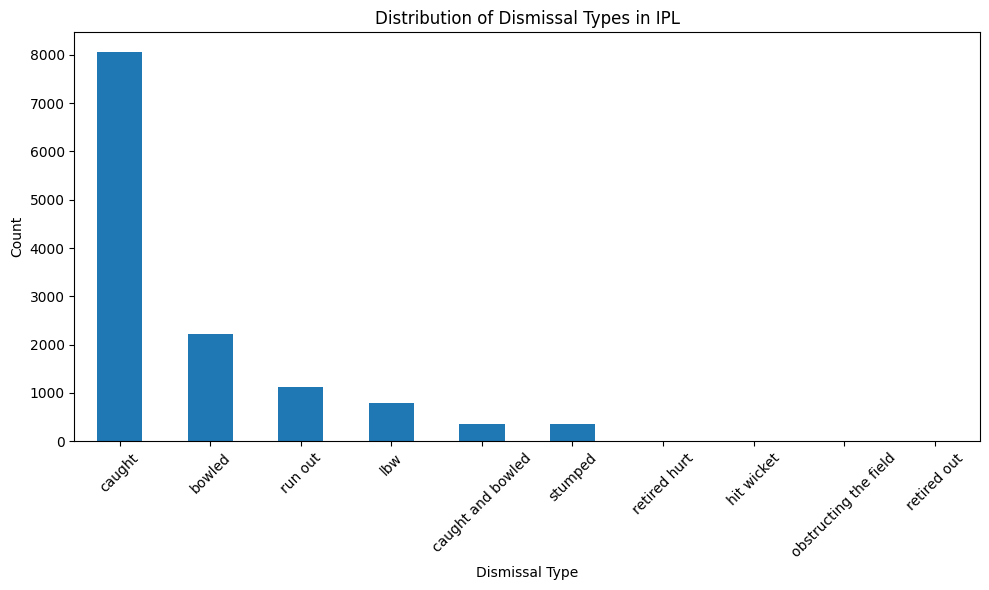

In [10]:
# 6. Visualization

plt.figure(figsize=(10,6))
dismissal_counts.plot(kind='bar')

plt.title("Distribution of Dismissal Types in IPL")
plt.xlabel("Dismissal Type")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()